### Title: PI Simulation

### Objectives:
* To understand the concept and significance of the mathematical constant π (Pi).
* To estimate the value of π using the Monte Carlo simulation method.
* To observe the effect of increasing the number of random points on the accuracy of the estimated value of π.
### Theory: 
### Introduction to π (Pi)

Pi (π) is a mathematical constant that represents the ratio of the circumference of a circle to its diameter. Its approximate value is 3.14159. Since π is an irrational number, it cannot be expressed as a fraction of two integers (a/b,b

=0). It is also a non-terminating and non-recurring decimal.

### History of π
The Babylonians and Egyptians approximated π as 3.125 and used it in geometry, architecture, and astronomy.
The Greek mathematician Archimedes developed the polygon method to estimate π, obtaining values between 3.1408 and 3.1429.

### Applications of π
Pi has numerous applications in mathematics, science, and engineering:

Scientific formulas: Thermodynamics, cosmology, and electromagnetics.
Natural phenomena: Ocean waves, sound waves, and radioactive particle motion.
Geometry: Calculating the area and circumference of a circle, and the surface area and volume of a sphere.
Algorithms to Generate π

### Some common methods used to calculate π are:

* Madhava–Leibniz Formula
* Wallis Product
* Monte Carlo Method

### Monte Carlo Method

The Monte Carlo method is a statistical simulation technique that uses random numbers to estimate the value of π.
In this method:

A square is drawn with an inscribed circle.
Random points are generated uniformly inside the square.
The number of points that fall inside the circle is counted.
Since the ratio of the area of the circle to the area of the square is π/4, π can be estimated using:
π≈4×
Total number of random points
Number of points inside the circle
	​
As the number of randomly generated points increases, the estimated value of π becomes more accurate. This follows the Law of Large Numbers, which states that the average result obtained from many trials approaches the true value.

In [ ]:
from __future__ import division
from random import random
from math import pi
import matplotlib.pyplot as plt
import sys


def rain_drop(length_of_field=1):
    """
    Simulate a random rain drop within the field.
    """
    return [
        (0.5 - random()) * length_of_field,
        (0.5 - random()) * length_of_field
    ]


def is_point_in_circle(point, length_of_field=1):
    """
    Check if a point lies within the inscribed circle.
    """
    return point[0]**2 + point[1]**2 <= (length_of_field / 2)**2


def plot_rain_drops(drops_in_circle, drops_out_of_circle, length_of_field=1, format='png'):
    """
    Plot the raindrops in and out of the circle.
    """
    plt.figure()
    plt.xlim(-length_of_field / 2, length_of_field / 2)
    plt.ylim(-length_of_field / 2, length_of_field / 2)

    plt.scatter(
        [e[0] for e in drops_in_circle],
        [e[1] for e in drops_in_circle],
        color='blue',
        label="Drops in circle"
    )

    plt.scatter(
        [e[0] for e in drops_out_of_circle],
        [e[1] for e in drops_out_of_circle],
        color='black',
        label="Drops out of circle"
    )

    plt.legend(loc="center")

    plt.title(
        f"{len(drops_in_circle) + len(drops_out_of_circle)} drops: "
        f"{len(drops_in_circle)} landed in circle, "
        f"estimating π as "
        f"{4 * len(drops_in_circle) / (len(drops_in_circle) + len(drops_out_of_circle)):.4f}"
    )

    plt.savefig(f"rain_drops.{format}")
    plt.close()


def plot_pi_estimates(pi_estimate, total_drops):
    """
    Plot the π estimates as a function of the number of drops.
    """
    plt.figure()

    plt.scatter(range(1, total_drops + 1), pi_estimate, s=1)

    plt.hlines(
        pi,
        0,
        total_drops,
        color='black',
        linestyle='dashed',
        label="Actual π"
    )

    plt.xlim(0, total_drops)
    plt.title("π Estimate Against Number of Rain Drops")
    plt.xlabel("Number of Rain Drops")
    plt.ylabel("π")
    plt.legend()

    plt.savefig(f"pi_estimate_{total_drops}_drops.png")
    plt.close()


def rain(number_of_drops=1000, length_of_field=1, plot=True, dynamic=False):
    """
    Simulate raindrops to estimate π.
    """
    number_of_drops_in_circle = 0
    drops_in_circle = []
    drops_out_of_circle = []
    pi_estimate = []

    for k in range(number_of_drops):
        drop = rain_drop(length_of_field)

        if is_point_in_circle(drop, length_of_field):
            drops_in_circle.append(drop)
            number_of_drops_in_circle += 1
        else:
            drops_out_of_circle.append(drop)

        # Update π estimate
        pi_estimate.append(4 * number_of_drops_in_circle / (k + 1))

        # Optional dynamic plotting
        if dynamic:
            plot_rain_drops(
                drops_in_circle,
                drops_out_of_circle,
                length_of_field,
                format='png'
            )

    # Final plots
    if plot and not dynamic:
        plot_rain_drops(
            drops_in_circle,
            drops_out_of_circle,
            length_of_field
        )
        plot_pi_estimates(pi_estimate, number_of_drops)

    return number_of_drops_in_circle, number_of_drops


if __name__ == "__main__":
    number_of_drops = int(input("Enter the number of drops: "))
    try:
        if len(sys.argv) > 1:
            # Use command-line argument if provided
            number_of_drops = int(sys.argv[1])
        else:
            # Ask user for input
            number_of_drops = int(input("Enter the number of drops: "))

        # Simulate raindrops
        result = rain(number_of_drops, plot=True, dynamic=False)

        print("----------------------")
        print(f"{number_of_drops} drops")
        print(f"π estimated as: {4 * result[0] / result[1]:.6f}")
        print(f"Actual π: {pi:.6f}")
        print("----------------------")

    except ValueError:
        print("Invalid input! Please provide an integer for the number of drops.")

Invalid input! Please provide an integer for the number of drops.


----------------------
1000 drops
π estimated as: 3.132000
Actual π: 3.141593
----------------------


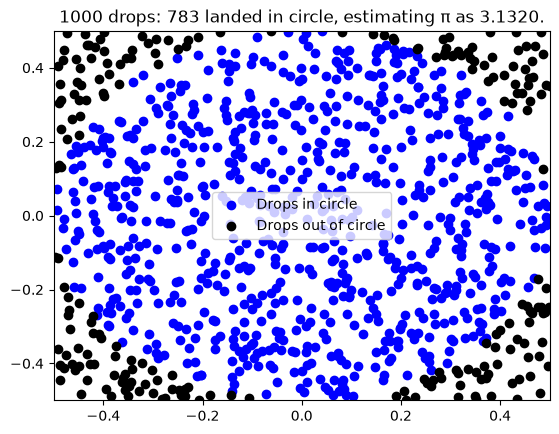

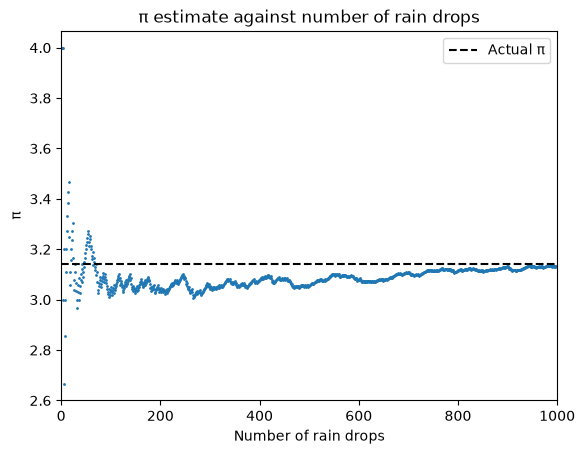

In [10]:
from __future__ import division
from random import random
from math import pi
import matplotlib.pyplot as plt
import sys


def rain_drop(length_of_field=1):
    """
    Simulate a random rain drop within the field.
    """
    return [
        (.5 - random()) * length_of_field,
        (.5 - random()) * length_of_field
    ]


def is_point_in_circle(point, length_of_field=1):
    """
    Check if a point lies within the inscribed circle.
    """
    return (point[0]) ** 2 + (point[1]) ** 2 <= (length_of_field / 2) ** 2


def plot_rain_drops(drops_in_circle, drops_out_of_circle,
                    length_of_field=1, format='png'):
    """
    Plot the raindrops in and out of the circle.
    """
    plt.figure()
    plt.xlim(-length_of_field / 2, length_of_field / 2)
    plt.ylim(-length_of_field / 2, length_of_field / 2)

    plt.scatter(
        [e[0] for e in drops_in_circle],
        [e[1] for e in drops_in_circle],
        color='blue',
        label="Drops in circle"
    )

    plt.scatter(
        [e[0] for e in drops_out_of_circle],
        [e[1] for e in drops_out_of_circle],
        color='black',
        label="Drops out of circle"
    )

    plt.legend(loc="center")
    plt.title(
        f"{len(drops_in_circle) + len(drops_out_of_circle)} drops: "
        f"{len(drops_in_circle)} landed in circle, "
        f"estimating π as "
        f"{4 * len(drops_in_circle) / (len(drops_in_circle) + len(drops_out_of_circle)):.4f}."
    )

    plt.savefig(f"rain_drops.{format}")


def plot_pi_estimates(pi_estimate, total_drops):
    """
    Plot the π estimates as a function of the number of drops.
    """
    plt.figure()

    plt.scatter(range(1, total_drops + 1), pi_estimate, s=1)

    plt.hlines(
        pi,
        0,
        total_drops,
        color='black',
        linestyle='dashed',
        label="Actual π"
    )

    plt.xlim(0, total_drops)
    plt.title("π estimate against number of rain drops")
    plt.xlabel("Number of rain drops")
    plt.ylabel("π")
    plt.legend()

    plt.savefig(f"pi_estimate_{total_drops}_drops.png")


def rain(number_of_drops=1000, length_of_field=1,
         plot=True, dynamic=False):
    """
    Simulate raindrops to estimate π.
    """
    number_of_drops_in_circle = 0
    drops_in_circle = []
    drops_out_of_circle = []
    pi_estimate = []

    for k in range(number_of_drops):

        drop = rain_drop(length_of_field)

        if is_point_in_circle(drop, length_of_field):
            drops_in_circle.append(drop)
            number_of_drops_in_circle += 1
        else:
            drops_out_of_circle.append(drop)

        # Update π estimate
        pi_estimate.append(4 * number_of_drops_in_circle / (k + 1))

        # Optional dynamic plotting
        if dynamic:
            plot_rain_drops(
                drops_in_circle,
                drops_out_of_circle,
                length_of_field,
                format='png'
            )

    # Final plots
    if plot and not dynamic:
        plot_rain_drops(
            drops_in_circle,
            drops_out_of_circle,
            length_of_field
        )

        plot_pi_estimates(pi_estimate, number_of_drops)

    return number_of_drops_in_circle, number_of_drops


if __name__ == "__main__":
    number_of_drops = int(input("Enter the number of drops: "))

result = rain(number_of_drops, plot=True, dynamic=False)

print("----------------------")
print(f"{number_of_drops} drops")
print(f"π estimated as: {4 * result[0] / result[1]:.6f}")
print(f"Actual π: {pi:.6f}")
print("----------------------")

### Discussion

The Monte Carlo simulation was used to estimate the value of π by randomly generating 1000 points within a square and determining how many fell inside the inscribed circle. The simulation produced an estimated value of π = 3.132000, while the actual value of π is 3.141593.

The estimated value differs from the actual value by approximately 0.009593, which is a relatively small error. This difference occurs because the Monte Carlo method relies on random sampling, and with only 1000 points, statistical fluctuations are expected. As the number of randomly generated points increases, the estimate generally becomes more accurate due to the Law of Large Numbers. The generated plots also illustrate the random distribution of points and the convergence of the estimated value of π toward the actual value as more samples are considered.

### Conclusion

The experiment successfully demonstrated the estimation of π using the Monte Carlo simulation method. With 1000 random drops, the estimated value of π was 3.132000, which is close to the actual value of 3.141593. The results confirm that the Monte Carlo method is an effective probabilistic approach for approximating π. Increasing the number of random points would further reduce the estimation error and produce a value even closer to the true value of π.